In [71]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [81]:
df = pd.DataFrame({
    'Experience': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary': [30, 35, 43, 54, 68, 85, 105, 128, 154, 183]
})

print(df)

   Experience  Salary
0           1      30
1           2      35
2           3      43
3           4      54
4           5      68
5           6      85
6           7     105
7           8     128
8           9     154
9          10     183


[]

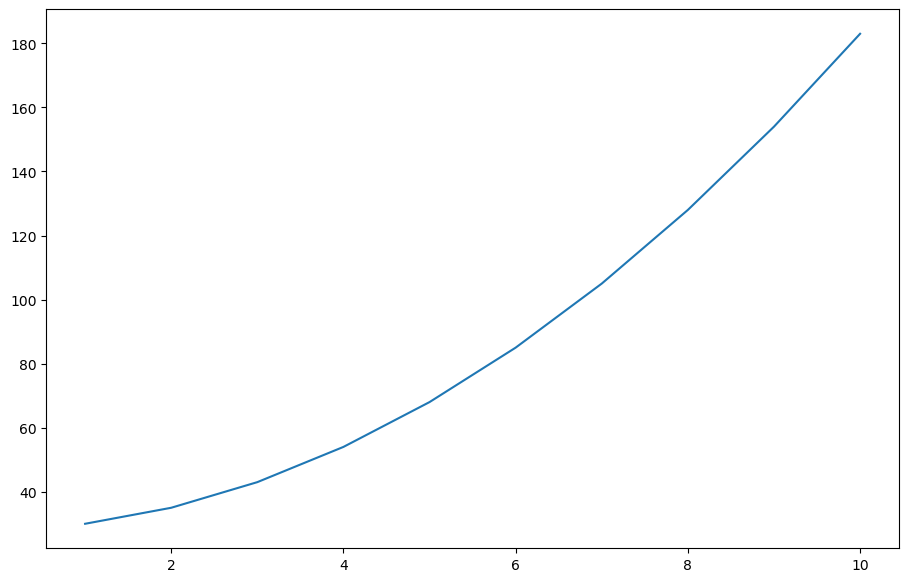

In [99]:
plt.figure(figsize=(11,7))
plt.plot(df['Experience'],df['Salary'])
plt.plot()
#in this case we will be using polynomial regression because 
#the line is completely curved...

In [83]:
#separate x and y
x = df[['Experience']]
y = df['Salary']

In [84]:
#create polynomial features
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

In [85]:
print("\n Polynomial Features")
print(x_poly)


 Polynomial Features
[[  1.   1.   1.]
 [  1.   2.   4.]
 [  1.   3.   9.]
 [  1.   4.  16.]
 [  1.   5.  25.]
 [  1.   6.  36.]
 [  1.   7.  49.]
 [  1.   8.  64.]
 [  1.   9.  81.]
 [  1.  10. 100.]]


In [86]:
model = LinearRegression()
model.fit(x_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
#predictions
y_pred = model.predict(x_poly)

print("\nPredictions")
print(y_pred)


Predictions
[ 30.  35.  43.  54.  68.  85. 105. 128. 154. 183.]


In [90]:
#evaluation
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

In [91]:
print("Mean Squared Error", mse)
print("R2 Score", r2)

Mean Squared Error 3.029225876048685e-29
R2 Score 1.0


In [94]:
print("\n Equation")

print(
    f"Salary = {model.intercept_:.2f}"
    f"+ {model.coef_[1]:.2f}x"
    f"+ {model.coef_[2]:.2f}X²"
)
    


 Equation
Salary = 28.00+ 0.50x+ 1.50X²


In [95]:
new_experience = [[6.5]]

new_experience_poly = poly.transform(new_experience)

prediction = model.predict(new_experience_poly)

print("\nPredicted salary for 6.5 years:")
print(prediction[0])



Predicted salary for 6.5 years:
94.625


C:\Users\ashim\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


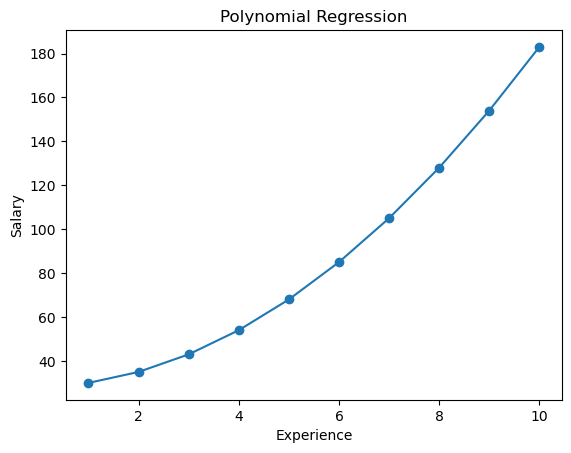

In [97]:
plt.scatter(x, y)

plt.plot(x, y_pred)

plt.xlabel("Experience")
plt.ylabel("Salary")

plt.title("Polynomial Regression")

plt.show()